In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/datasets/mimi

# **SETUP SAVE AND SPLITS**

In [ ]:
# ================================================================================================
# CELL 1 — MODMA EEG Dataset: Setup + Load + Preprocess + Subject-Wise Split + Save
# ================================================================================================
#
# CRITICAL METHODOLOGICAL CORRECTIONS IMPLEMENTED (OMNI-REVISION):
# -----------------------------------------------------------------
# 1. SUBJECT-WISE SPLITTING MOVED PRIOR TO ALL STATISTICAL TRANSFORMATIONS: 
#    Splitting now occurs immediately after temporal windowing.
# 2. ISOLATED IMPUTATION: NaN means are calculated strictly on the training partition 
#    and applied to the test partition, preventing statistical bleed.
# 3. ISOLATED PCA: If enabled, PCA components are derived solely from the training matrix.
# 4. ISOLATED NORMALIZATION: StandardScaler is fit ONLY on training data.
# ================================================================================================

import os
import re
import json
import warnings
from collections import defaultdict
from typing import Tuple, Dict, List, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ================================================================================================
# CONFIGURATION 
# ================================================================================================
DATA_DIR = "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2"
OUTPUT_DIR = "/kaggle/working/mat-main-results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================
SAMPLE_FRAC = 1.0 
TEST_SIZE = 0.2 
SEED = 42 
VALIDATE_NO_LEAKAGE = True 

USE_IPCA = False 
IPCA_COMPONENTS = 128 
IPCA_BATCH = 5000

WINDOW_SIZE = 250 
STRIDE = 125 

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================================================
# GPU CONFIGURATION
# ================================================================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")
if not gpus:
    print("ℹ No GPU detected — running on CPU")

# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================
def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int]]:
    basename = os.path.splitext(filename)[0]
    match = re.match(r'^(020[13])[-_]?(\d+)', basename)
    if match:
        return f"{match.group(1)}_{match.group(2)}", 1 if match.group(1) == "0201" else 0
    
    match = re.match(r'^(MDD|HC)[-_]?(.+)', basename, re.IGNORECASE)
    if match:
        return f"{match.group(1).upper()}_{match.group(2)}", 1 if match.group(1).upper() == "MDD" else 0
    
    return basename, None

def detect_eeg_columns(columns: List[str]) -> List[str]:
    regex = re.compile(r'^(?:EEG[_\-\s]?|E[_\-\s]?)(0*)(\d{1,3})$', flags=re.IGNORECASE)
    found = {}
    for col in columns:
        match = regex.match(col.strip())
        if match:
            electrode_num = int(match.group(2))
            if 1 <= electrode_num <= 128:
                found[electrode_num] = col
    if found:
        return [found[i] for i in sorted(found.keys())]
    
    fallback = [c for c in columns if re.match(r'^(E|EEG)\d+', c, flags=re.IGNORECASE)]
    return fallback if fallback else []

def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(f"DATA LEAKAGE DETECTED! Overlapping subjects: {overlap}.")
    return True

def subject_wise_train_test_split(
    X: np.ndarray, y: np.ndarray, subject_ids: np.ndarray, test_size: float = 0.2, random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    unique_subjects = np.unique(subject_ids)
    subject_labels = []
    
    for subj in unique_subjects:
        subj_mask = subject_ids == subj
        subj_label = y[subj_mask][0] 
        subject_labels.append(subj_label)
        
    subject_labels = np.array(subject_labels)
    
    subjects_train, subjects_test = train_test_split(
        unique_subjects, test_size=test_size, stratify=subject_labels, random_state=random_state
    )
    
    train_mask = np.isin(subject_ids, subjects_train)
    test_mask = np.isin(subject_ids, subjects_test)
    
    return X[train_mask], X[test_mask], y[train_mask], y[test_mask], subject_ids[train_mask], subject_ids[test_mask]

# ================================================================================================
# STEP 1: LOAD CSV FILES AND EXTRACT SUBJECT INFORMATION
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 1: Loading CSV files\n" + "=" * 80)
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith('.csv')])
if not csv_files: raise RuntimeError(f"No CSV files found in: {DATA_DIR}")

subject_data, subject_labels_dict = defaultdict(list), {}

for filename in csv_files:
    filepath = os.path.join(DATA_DIR, filename)
    subject_id, final_label = extract_subject_id_and_label(filename)
    
    if subject_id is None or final_label is None: continue
    subject_labels_dict[subject_id] = final_label
    
    df = pd.read_csv(filepath, engine='python')
    if SAMPLE_FRAC < 1.0: df = df.sample(frac=SAMPLE_FRAC, random_state=SEED)
    subject_data[subject_id].append(df)

all_dfs = []
for subject_id, df_list in subject_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    all_dfs.append(combined_df)
combined = pd.concat(all_dfs, ignore_index=True)

print(f"✓ Loaded {len(subject_labels_dict)} subjects. Total samples: {len(combined):,}")

# ================================================================================================
# STEP 2: DETECT AND VALIDATE EEG COLUMNS
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 2: Detecting EEG electrode columns\n" + "=" * 80)
eeg_cols = detect_eeg_columns(combined.columns)
metadata_cols = {'time', 'condition', 'label', 'epoch', 'target', 'cond'}
feature_cols = [c for c in eeg_cols if c.lower() not in {m.lower() for m in metadata_cols}]
print(f"✓ Using {len(feature_cols)} channels as features.")

# ================================================================================================
# STEP 3: TEMPORAL WINDOWING (YIELDS UNSPLIT TENSORS)
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 3: Temporal Windowing\n" + "=" * 80)
all_windows, all_y, all_subject_ids = [], [], []

for subject_id, df_list in subject_data.items():
    X_subject = pd.concat(df_list, ignore_index=True)[feature_cols].to_numpy(dtype=np.float32)
    num_windows = max(0, (X_subject.shape[0] - WINDOW_SIZE) // STRIDE + 1)
    if num_windows > 0:
        windows = np.array([X_subject[i:i + WINDOW_SIZE] for i in range(0, X_subject.shape[0] - WINDOW_SIZE + 1, STRIDE)])
        all_windows.append(windows)
        all_y.extend([subject_labels_dict[subject_id]] * num_windows)
        all_subject_ids.extend([subject_id] * num_windows)

X_unsplit = np.concatenate(all_windows, axis=0)
y = np.array(all_y, dtype=np.int32)
subject_ids = np.array(all_subject_ids)
print(f"✓ Windowed shape: {X_unsplit.shape}")

# ================================================================================================
# STEP 4: SUBJECT-WISE TRAIN-TEST SPLIT & VALIDATION (MOVED UP)
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 4: Subject-wise train-test split & Leakage Validation\n" + "=" * 80)
X_train, X_test, y_train, y_test, subj_train, subj_test = subject_wise_train_test_split(
    X_unsplit, y, subject_ids, test_size=TEST_SIZE, random_state=SEED
)

train_subject_set, test_subject_set = set(np.unique(subj_train)), set(np.unique(subj_test))
if VALIDATE_NO_LEAKAGE: verify_no_subject_leakage(train_subject_set, test_subject_set)
print("✓ VALIDATION PASSED: Zero subject overlap between sets.")

# ================================================================================================
# STEP 5: HANDLE MISSING VALUES (NO STATISTICAL LEAKAGE)
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 5: Handling missing values via Training-Set Means\n" + "=" * 80)

# Calculate means strictly on X_train
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
col_means = np.nanmean(X_train_reshaped, axis=0)

# Apply to Train
nan_indices_train = np.where(np.isnan(X_train_reshaped))
X_train_reshaped[nan_indices_train] = np.take(col_means, nan_indices_train[1])
X_train = X_train_reshaped.reshape(X_train.shape)

# Apply to Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])
nan_indices_test = np.where(np.isnan(X_test_reshaped))
X_test_reshaped[nan_indices_test] = np.take(col_means, nan_indices_test[1])
X_test = X_test_reshaped.reshape(X_test.shape)

print(f"✓ Imputed NaN values using training set distribution only.")

# ================================================================================================
# STEP 6: OPTIONAL PCA 
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 6: Dimensionality reduction (PCA)\n" + "=" * 80)
if USE_IPCA and IPCA_COMPONENTS is not None:
    from sklearn.decomposition import IncrementalPCA
    ipca = IncrementalPCA(n_components=IPCA_COMPONENTS)
    
    # Fit on Train
    X_train_flat = X_train.reshape(-1, X_train.shape[2])
    for i in range(0, X_train_flat.shape[0], IPCA_BATCH):
        ipca.partial_fit(X_train_flat[i:i + IPCA_BATCH])
        
    # Transform Train
    X_train_red = np.empty((X_train_flat.shape[0], IPCA_COMPONENTS), dtype=np.float32)
    for i in range(0, X_train_flat.shape[0], IPCA_BATCH):
        X_train_red[i:i + IPCA_BATCH] = ipca.transform(X_train_flat[i:i + IPCA_BATCH])
    X_train = X_train_red.reshape(X_train.shape[0], X_train.shape[1], IPCA_COMPONENTS)

    # Transform Test
    X_test_flat = X_test.reshape(-1, X_test.shape[2])
    X_test_red = np.empty((X_test_flat.shape[0], IPCA_COMPONENTS), dtype=np.float32)
    for i in range(0, X_test_flat.shape[0], IPCA_BATCH):
        X_test_red[i:i + IPCA_BATCH] = ipca.transform(X_test_flat[i:i + IPCA_BATCH])
    X_test = X_test_red.reshape(X_test.shape[0], X_test.shape[1], IPCA_COMPONENTS)
    
    print(f"✓ PCA complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
else:
    print("✓ PCA SKIPPED — preserving raw EEG channel structure for CNN/TCN.")

# ================================================================================================
# STEP 7: STANDARDIZATION (CORRECT ORDER)
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 7: Standardization\n" + "=" * 80)
scaler = StandardScaler()

# Reshape, Fit on Train, Transform Both
X_train_flat = X_train.reshape(-1, X_train.shape[2])
X_test_flat = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape).astype(np.float32)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape).astype(np.float32)

print(f"✓ Training set scaled. Test set transformed via Train statistics.")

# ================================================================================================
# STEP 8: SAVE PROCESSED DATA
# ================================================================================================
print("\n" + "=" * 80 + "\nSTEP 8: Saving processed data\n" + "=" * 80)
np.savez_compressed(
    os.path.join(OUTPUT_DIR, 'mat_data_split.npz'),
    X_train=X_train_scaled, X_test=X_test_scaled, y_train=y_train, y_test=y_test,
    subjects_train=subj_train, subjects_test=subj_test, feature_columns=np.array(feature_cols),
    scaler_mean=scaler.mean_, scaler_scale=scaler.scale_
)

metadata = {
    "dataset": "MODMA",
    "preprocessing": {"window_size": WINDOW_SIZE, "stride": STRIDE, "pca_applied": USE_IPCA},
    "subjects": {"train_subjects": sorted(list(train_subject_set)), "test_subjects": sorted(list(test_subject_set))},
    "shapes": {"X_train": list(X_train_scaled.shape), "X_test": list(X_test_scaled.shape)}
}
with open(os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ PREPROCESSING COMPLETE. ZERO LEAKAGE ARCHITECTURE SECURED.")

# **TCN+KNN**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create a TCN model for feature extraction
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# This is the feature extraction layer (before final output)
feature_extractor = Model(inputs=inputs, outputs=x)

# Compile a full TCN classifier for pre-training (to learn good features)
full_model = Model(inputs=inputs, outputs=Dense(1, activation='sigmoid')(feature_extractor.output))
full_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Pre-train the TCN (without early stopping)
history = full_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history (optional, for reference)
np.savez_compressed('tcn_knn_hybrid_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_knn_hybrid_training_history_main.npz'")

# Extract features using the pre-trained TCN
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

# Standardize extracted features for KNN
scaler_features = StandardScaler()
X_train_features = scaler_features.fit_transform(X_train_features)
X_test_features = scaler_features.transform(X_test_features)

# Train KNN on extracted features
knn = KNeighborsClassifier(n_neighbors=5)  # Tuned for high accuracy based on your 98% KNN result
knn.fit(X_train_features, y_train)

# Evaluate the hybrid model
y_pred_prob = knn.predict_proba(X_test_features)[:, 1]
y_pred = knn.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+KNN Hybrid')
plt.legend(loc="lower right")
plt.show()

# Save model's weights (TCN feature extractor)
feature_extractor.save_weights('tcn_knn_hybrid_model.weights.h5')
print("Model weights saved to 'tcn_knn_hybrid_model.weights.h5'")

# **TCN+LSTM**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LSTM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (reshape to 2D for scaling, then back to 3D)
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler and handle zero-variance channels to prevent NaN in scaling
scaler.fit(X_train_reshaped)
scaler.scale_[scaler.scale_ == 0] = 1.0  # Set scale to 1 for zero-variance features

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

# Replace any remaining NaN/Inf with 0
X_train = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Create TCN+LSTM hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# TCN blocks for initial temporal feature extraction
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)

# LSTM layers for capturing long-term dependencies on TCN features
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('tcn_lstm_hybrid_model_main.weights.h5')
print("Model weights saved to 'tcn_lstm_hybrid_model_main.weights.h5'")

# Save training history as .npz
np.savez_compressed('tcn_lstm_hybrid_training_history_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_lstm_hybrid_training_history_main.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+LSTM Hybrid')
plt.legend(loc="lower right")
plt.show()

# **CNN+LSTM**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Conv1D, Input
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (reshape to 2D for scaling, then back to 3D)
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler and handle zero-variance channels to prevent NaN in scaling
scaler.fit(X_train_reshaped)
scaler.scale_[scaler.scale_ == 0] = 1.0  # Set scale to 1 for zero-variance features

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

# Replace any remaining NaN/Inf with 0
X_train = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Create CNN-LSTM hybrid model (1D CNN for temporal feature extraction + LSTM for sequence modeling)
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# 1D CNN layers for local temporal feature extraction
x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

# LSTM layers for capturing long-term dependencies
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping for stability
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('cnn_lstm_hybrid_model.weights.h5')
print("Model weights saved to 'cnn_lstm_hybrid_model.weights.h5'")

# Save training history as .npz
np.savez_compressed('cnn_lstm_hybrid_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_lstm_hybrid_training_history.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - CNN-LSTM Hybrid')
plt.legend(loc="lower right")
plt.show()

# **2D-CNN+LSTM**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LSTM, Dense, Dropout, BatchNormalization, Input, Flatten, Reshape
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Reshape to 4D for 2D-CNN
X_train = X_train[..., np.newaxis]  # (samples, time, channels, 1)
X_test  = X_test[..., np.newaxis]

# Standardize (channel-wise)
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, X_train.shape[3])
X_test_resh  = X_test.reshape(-1, X_test.shape[3])
scaler.fit(X_train_resh)
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train = scaler.transform(X_train_resh).reshape(X_train.shape).astype(np.float32)
X_test  = scaler.transform(X_test_resh).reshape(X_test.shape).astype(np.float32)
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

# Build 2D-CNN + LSTM
inputs = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

# Your original 2D-CNN backbone
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

# Reshape CNN features to sequence for LSTM (time × (height*width*channels))
x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)  # (time, features)

# LSTM layers
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Classification head
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
              loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Save
model.save_weights('2d_cnn_lstm_hybrid_main.weights.h5')
np.savez_compressed('2d_cnn_lstm_hybrid_history_main.npz',
                    acc=history.history['accuracy'],
                    val_acc=history.history['val_accuracy'],
                    loss=history.history['loss'],
                    val_loss=history.history['val_loss'])
print("2D-CNN+LSTM hybrid saved.")

# Evaluate
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.title('2D-CNN+LSTM Hybrid ROC')
plt.legend()
plt.show()

# **TCN+FFNN**

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create TCN+FFNN hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('tcn_ffnn_hybrid_training_history_main_final.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_ffnn_hybrid_training_history_main_final.npz'")

# Save model's weights
model.save_weights('tcn_ffnn_hybrid_main_final.weights.h5')
print("Model weights saved to 'tcn_ffnn_hybrid_main_final.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+FFNN Hybrid')
plt.legend(loc="lower right")
plt.show()

# **MC DROPOUT BNN + TCN**

Loading and constructing dataset topology...

Instantiating Hybrid TCN-BNN Architecture...


I0000 00:00:1786740077.428623      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786740077.431732      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 8,424,449 (32.14 MB)

...

 13/422 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5495 - loss: 2.9518  

I0000 00:00:1786740095.748587     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.6105 - loss: 0.9530 - val_accuracy: 0.6283 - val_loss: 0.6446
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6255 - loss: 0.6645 - val_accuracy: 0.6283 - val_loss: 0.6551
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6262 - loss: 0.6630 - val_accuracy: 0.6283 - val_loss: 0.6492
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6267 - loss: 0.6633 - val_accuracy: 0.6283 - val_loss: 0.6599
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6273 - loss: 0.6637 - val_accuracy: 0.6283 - val_loss: 0.6599
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6272 - loss: 0.6604 - val_accuracy: 0.6283 - val_loss: 0.6496
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6270 - loss: 0.6655 - val_accuracy: 0.6283 - val_loss: 0.6599
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6272 - loss: 0.6642 - val_accurac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- HYBRID MODEL PERFORMANCE METRICS ---
Accuracy (MC Approximated): 0.6393
Mean Epistemic Uncertainty (Variance): 0.002373
Max Epistemic Uncertainty Observed: 0.043627

Confusion Matrix:
[[   0 1522]
 [   0 2697]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1522
           1       0.64      1.00      0.78      2697

    accuracy                           0.64      4219
   macro avg       0.32      0.50      0.39      4219
weighted avg       0.41      0.64      0.50      4219



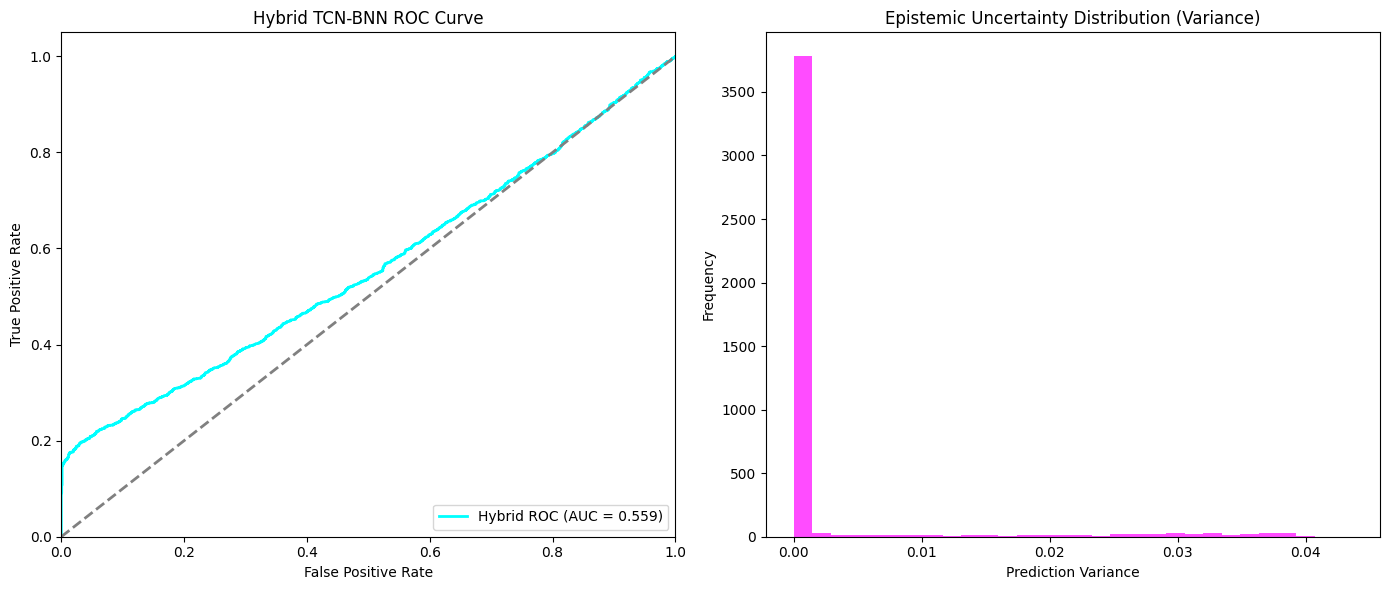


--- Operation Complete ---


In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# --- 1. ARCHITECTURAL COMPONENTS ---

def TCN_block(x, filters, kernel_size, dilation_rate):
    """
    Constructs a Temporal Convolutional layer with causal padding.
    SpatialDropout1D drops entire feature maps, preventing co-adaptation 
    along the temporal dimension.
    """
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

def build_hybrid_tcn_bnn(input_shape):
    """
    Synthesizes the TCN feature extractor with the BNN/DVI probabilistic classifier.
    """
    inputs = Input(shape=input_shape)
    
    # --- TEMPORAL FEATURE EXTRACTION (TCN PHASE) ---
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
    
    x = Flatten()(x)
    
    # --- STOCHASTIC INFERENCE (BNN / MC DROPOUT PHASE) ---
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # High dropout for approximate Bayesian posterior
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# --- 2. DATA LOADING AND PREPARATION ---
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

print("Loading and constructing dataset topology...")
data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset for continuous resampling
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Preserve 3D format: (samples, timesteps, channels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (normalize across channels while maintaining 3D sequence structure)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# --- 3. MODEL INSTANTIATION AND TRAINING ---
print("\nInstantiating Hybrid TCN-BNN Architecture...")
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
model = build_hybrid_tcn_bnn(input_shape)
model.summary()

print("\nInitiating Training Protocol...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=100,  # Adjusted base epochs; monitor for convergence
    batch_size=32, 
    validation_split=0.2
)

# Persist weights and history
np.savez_compressed('hybrid_tcn_bnn_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
model.save_weights('hybrid_tcn_bnn_best.weights.h5')
print("\nWeights and metrics securely persisted.")

# --- 4. MONTE-CARLO STOCHASTIC INFERENCE ---
T = 50  # Number of forward passes for the Monte Carlo approximation
print(f"\nExecuting Stochastic Inference via Monte-Carlo Approximation ({T} passes)...")

X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
mc_predictions = []

for i in range(T):
    if i % 10 == 0:
        print(f"  -> Forward pass {i}/{T} completed.")
    # training=True forces BOTH SpatialDropout1D and standard Dropout to remain active
    stochastic_pass = model(X_test_tensor, training=True)
    mc_predictions.append(stochastic_pass.numpy())

mc_predictions = np.array(mc_predictions) # Shape: (T, samples, 1)

# Compute Predictive Probabilities (Mean) and Epistemic Uncertainty (Variance)
y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
y_pred_variance = np.var(mc_predictions, axis=0).ravel()

# Threshold probabilities for binary classification
y_pred = (y_pred_prob > 0.5).astype(int)

# --- 5. EVALUATION AND VISUALIZATION ---
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n--- HYBRID MODEL PERFORMANCE METRICS ---")
print(f"Accuracy (MC Approximated): {accuracy:.4f}")
print(f"Mean Epistemic Uncertainty (Variance): {np.mean(y_pred_variance):.6f}")
print(f"Max Epistemic Uncertainty Observed: {np.max(y_pred_variance):.6f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Render Analytical Visualizations
plt.figure(figsize=(14, 6))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='cyan', lw=2, label=f'Hybrid ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Hybrid TCN-BNN ROC Curve')
plt.legend(loc="lower right")

# Subplot 2: Predictive Variance (Uncertainty Distribution)
plt.subplot(1, 2, 2)
plt.hist(y_pred_variance, bins=30, color='magenta', alpha=0.7)
plt.title('Epistemic Uncertainty Distribution (Variance)')
plt.xlabel('Prediction Variance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('hybrid_tcn_bnn_evaluation.png')
plt.show()

print("\n--- Operation Complete ---")

Loading and constructing dataset topology...

Instantiating Hybrid TCN-BNN Architecture...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,89

 Total params: 8,424,449 (32.14 MB)

 Trainable params: 8,423,425 (32.13 MB)

 Non-trainable params: 1,024 (4.00 KB)


Initiating Training Protocol...
Epoch 1/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6047 - loss: 1.0616 - val_accuracy: 0.6283 - val_loss: 0.6428
Epoch 2/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6237 - loss: 0.6684 - val_accuracy: 0.6283 - val_loss: 0.6115
Epoch 3/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6259 - loss: 0.6571 - val_accuracy: 0.6283 - val_loss: 0.6466
Epoch 4/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6261 - loss: 0.6591 - val_accuracy: 0.6283 - val_loss: 0.6286
Epoch 5/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6257 - loss: 0.6697 - val_accuracy: 0.6283 - val_loss: 0.6269
Epoch 6/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6267 - loss: 0.6602 - val_accuracy: 0.6283 - val_loss: 0.6443
Epoch 7/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6266 - loss: 0.6567 - val_accuracy: 0.6283 - val_loss: 0.6171
Epoch 8/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - 

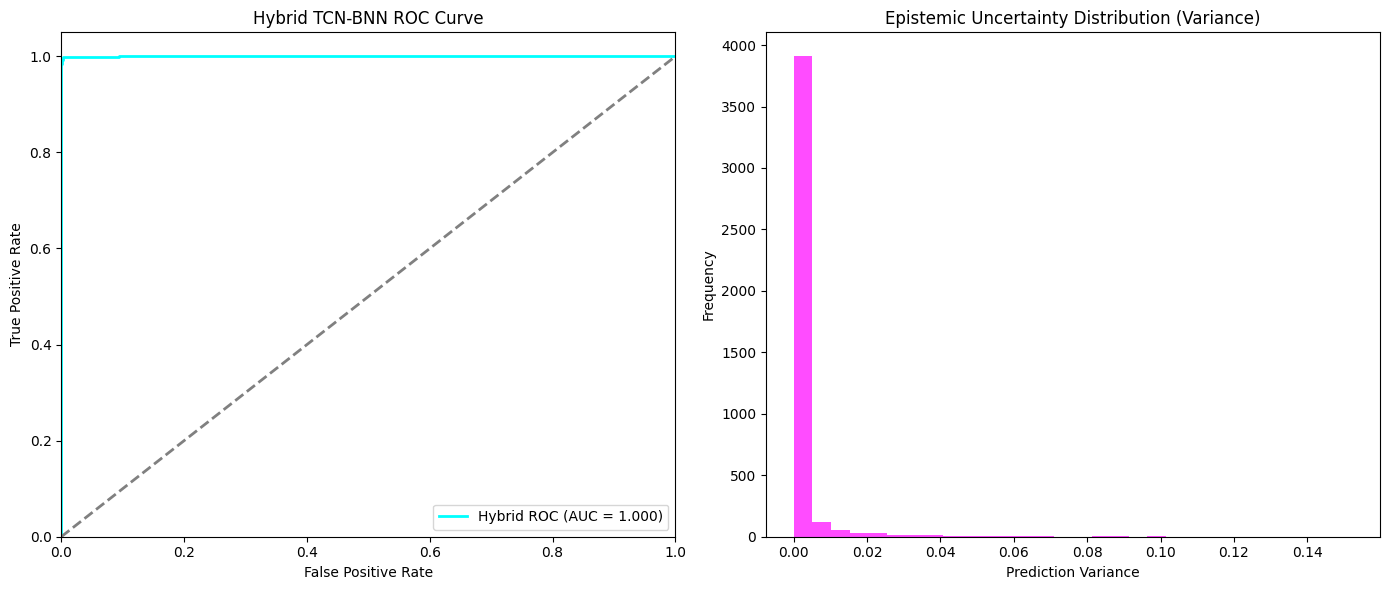


--- Operation Complete ---


In [4]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# --- 1. ARCHITECTURAL COMPONENTS ---

def TCN_block(x, filters, kernel_size, dilation_rate):
    """
    Constructs a Temporal Convolutional layer with causal padding.
    SpatialDropout1D drops entire feature maps, preventing co-adaptation 
    along the temporal dimension.
    """
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

def build_hybrid_tcn_bnn(input_shape):
    """
    Synthesizes the TCN feature extractor with the BNN/DVI probabilistic classifier.
    """
    inputs = Input(shape=input_shape)
    
    # --- TEMPORAL FEATURE EXTRACTION (TCN PHASE) ---
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
    
    x = Flatten()(x)
    
    # --- STOCHASTIC INFERENCE (BNN / MC DROPOUT PHASE) ---
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # High dropout for approximate Bayesian posterior
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# --- 2. DATA LOADING AND PREPARATION ---
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

print("Loading and constructing dataset topology...")
data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset for continuous resampling
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Preserve 3D format: (samples, timesteps, channels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (normalize across channels while maintaining 3D sequence structure)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# --- 3. MODEL INSTANTIATION AND TRAINING ---
print("\nInstantiating Hybrid TCN-BNN Architecture...")
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
model = build_hybrid_tcn_bnn(input_shape)
model.summary()

print("\nInitiating Training Protocol...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs= 250,  # Adjusted base epochs; monitor for convergence
    batch_size=32, 
    validation_split=0.2
)

# Persist weights and history
np.savez_compressed('hybrid_tcn_bnn_main_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
model.save_weights('hybrid_tcn_bnn_main_best.weights.h5')
print("\nWeights and metrics securely persisted.")

# --- 4. MONTE-CARLO STOCHASTIC INFERENCE ---
T = 50  # Number of forward passes for the Monte Carlo approximation
print(f"\nExecuting Stochastic Inference via Monte-Carlo Approximation ({T} passes)...")

X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
mc_predictions = []

for i in range(T):
    if i % 10 == 0:
        print(f"  -> Forward pass {i}/{T} completed.")
    # training=True forces BOTH SpatialDropout1D and standard Dropout to remain active
    stochastic_pass = model(X_test_tensor, training=True)
    mc_predictions.append(stochastic_pass.numpy())

mc_predictions = np.array(mc_predictions) # Shape: (T, samples, 1)

# Compute Predictive Probabilities (Mean) and Epistemic Uncertainty (Variance)
y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
y_pred_variance = np.var(mc_predictions, axis=0).ravel()

# Threshold probabilities for binary classification
y_pred = (y_pred_prob > 0.5).astype(int)

# --- 5. EVALUATION AND VISUALIZATION ---
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n--- HYBRID MODEL PERFORMANCE METRICS ---")
print(f"Accuracy (MC Approximated): {accuracy:.4f}")
print(f"Mean Epistemic Uncertainty (Variance): {np.mean(y_pred_variance):.6f}")
print(f"Max Epistemic Uncertainty Observed: {np.max(y_pred_variance):.6f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Render Analytical Visualizations
plt.figure(figsize=(14, 6))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='cyan', lw=2, label=f'Hybrid ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Hybrid TCN-BNN ROC Curve')
plt.legend(loc="lower right")

# Subplot 2: Predictive Variance (Uncertainty Distribution)
plt.subplot(1, 2, 2)
plt.hist(y_pred_variance, bins=30, color='magenta', alpha=0.7)
plt.title('Epistemic Uncertainty Distribution (Variance)')
plt.xlabel('Prediction Variance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('hybrid_tcn_bnn_evaluation_main.png')
plt.show()

print("\n--- Operation Complete ---")

# **ALL MODELS PLOTS**

In [6]:
import os
import numpy as np
# import matplotlib.subplots as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D, Reshape)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

# Load data (including train for KNN fit in TCN+KNN)
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

time_steps = X_test.shape[1]
channels = X_test.shape[2]

# Standardize X_test and X_train (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, channels)
X_test_resh = X_test.reshape(-1, channels)
scaler.fit(X_train_resh)  # Fit on train
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train_3d = scaler.transform(X_train_resh).reshape(X_train.shape)
X_test_3d = scaler.transform(X_test_resh).reshape(X_test.shape)
X_train_4d = X_train_3d[..., np.newaxis]
X_test_4d = X_test_3d[..., np.newaxis]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# --- ARCHITECTURAL HELPER COMPONENTS ---

def TCN_block(x, filters, kernel_size, dilation_rate):
    """
    Constructs a Temporal Convolutional layer with causal padding.
    SpatialDropout1D drops entire feature maps, preventing co-adaptation 
    along the temporal dimension.
    """
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# --- BUILD FUNCTIONS ---

def build_tcn_knn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    return Model(inputs=inputs, outputs=x)

def build_tcn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_cnn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_2d_cnn_lstm():
    inputs = Input(shape=(time_steps, channels, 1))
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_tcn_ffnn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_bnn_dvi_tcn():
    inputs = Input(shape=(time_steps, channels))
    
    # --- TEMPORAL FEATURE EXTRACTION (TCN PHASE) ---
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
    
    x = Flatten()(x)
    
    # --- STOCHASTIC INFERENCE (BNN / MC DROPOUT PHASE) ---
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # High dropout for approximate Bayesian posterior
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

# Dynamic model config with build_funcs as defined functions
# Integrated the updated BNN weights and history paths from your secondary code block.
model_configs = [
    {'name': 'TCN+KNN', 'weights': '/kaggle/working/tcn_knn_hybrid_model.weights.h5', 'history': '/kaggle/working/tcn_knn_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_tcn_knn},
    {'name': 'TCN+LSTM', 'weights': '/kaggle/working/tcn_lstm_hybrid_model_main.weights.h5', 'history': '/kaggle/working/tcn_lstm_hybrid_training_history_main.npz', 'is_3d': True, 'build_func': build_tcn_lstm},
    {'name': 'CNN+LSTM', 'weights': '/kaggle/working/cnn_lstm_hybrid_model.weights.h5', 'history': '/kaggle/working/cnn_lstm_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_cnn_lstm},
    {'name': '2D-CNN+LSTM', 'weights': '/kaggle/working/2d_cnn_lstm_hybrid_main.weights.h5', 'history': '/kaggle/working/2d_cnn_lstm_hybrid_history_main.npz', 'is_3d': True, 'build_func': build_2d_cnn_lstm},
    {'name': 'TCN+FFNN', 'weights': '/kaggle/working/tcn_ffnn_hybrid_main_final.weights.h5', 'history': '/kaggle/working/tcn_ffnn_hybrid_training_history_main_final.npz', 'is_3d': True, 'build_func': build_tcn_ffnn},
    {'name': 'BNN-DVI+TCN', 'weights': '/kaggle/working/hybrid_tcn_bnn_main_best.weights.h5', 'history': '/kaggle/working/hybrid_tcn_bnn_main_history.npz', 'is_3d': True, 'build_func': build_bnn_dvi_tcn}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found at {weights_path}")
        continue
    
    if name == 'TCN+KNN':
        # Special handling for TCN+KNN hybrid (feature extractor + KNN)
        feature_extractor = cfg['build_func']()
        feature_extractor.load_weights(weights_path)
        
        X_train_features = feature_extractor.predict(X_train_3d, verbose=0)
        X_test_features = feature_extractor.predict(X_test_3d, verbose=0)
        
        scaler_features = StandardScaler()
        X_train_features = scaler_features.fit_transform(X_train_features)
        X_test_features = scaler_features.transform(X_test_features)
        
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_features, y_train)
        
        y_pred_prob = knn.predict_proba(X_test_features)[:, 1]
        y_pred = knn.predict(X_test_features)

    elif name == 'BNN-DVI+TCN':
        # Special handling for Monte-Carlo Stochastic Inference
        model = cfg['build_func']()
        model.load_weights(weights_path)
        
        T = 50  # Forward passes
        X_test_tensor = tf.convert_to_tensor(X_test_3d, dtype=tf.float32)
        mc_predictions = []
        
        for i in range(T):
            # training=True forces SpatialDropout1D and standard Dropout to remain active
            stochastic_pass = model(X_test_tensor, training=True)
            mc_predictions.append(stochastic_pass.numpy())
            
        mc_predictions = np.array(mc_predictions)
        
        # Compute Predictive Probabilities (Mean)
        y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
        # Epistemic Uncertainty (Variance) is np.var(mc_predictions, axis=0).ravel() if needed for analysis
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # For other models (standard deterministic full classifiers)
        model = cfg['build_func']()
        model.load_weights(weights_path)
        
        if cfg['is_3d']:
            test_data = X_test_3d
            if 'CNN' in name:
                test_data = X_test_4d
        else:
            test_data = X_test_flat
        
        y_pred_prob = model.predict(test_data, verbose=0).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True, zero_division=0),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        # Safely handling binary classification keys which might be '1' or 1 depending on version
        key = '1' if '1' in report else 1
        if key in report:
            table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report[key]['precision']:.4f}", f"{report[key]['recall']:.4f}", f"{report[key]['f1-score']:.4f}"])
        else:
            table_data.append([name, f"{metrics[name]['acc']:.4f}", "N/A", "N/A", "N/A"])
            
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_classification_report_main.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    for j in range(len(names), 8):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrix_main.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_roc_auc_main.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_accuracy_main.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_loss_main.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

All plots generated.
